# K Nearest Neighbors (KNN)

Is a categorical classification method. Registers observations and their assigned class. Then, for a new observation it will assign the closest class based on the K nearest neighbors to that new observation.

The method detail will be configured by having 
* a specific value of K --how many neighbors to consider--,
* the distance algorithm, to calculate which are the nearest neighbors, and
* the tie-breaking algorithm.

### The value of K
* with K = 1, the algorithm will assign to the new observation the same class as the closest historical point.
* with K > 1 the algorithm will assign to the new observation the class to which more of the K nearest neighbors pertain

### Breaking the tie
in case of a tie (same number of closest neighbors pertain to more than one class) the algorithm to break the tie can be:
  * prevent tie by always having an od K
  * Reduce K by 1 until the tie is broken
  * reduce K to 1 for this point and assign the class of the closest neighbor.
  * Assign a class randomly

## How do we chose K?
We want a K such that is cheap to implement (lowest possible) and has the best accuracy. So we increase K until it is impractical to make it bigger or it reports no accuracy improvement.

We want to reduce error significantly as we increase K.

1. We can "manually" increase K and calculate the error (1-accuracy) then, by plotting those (K vs. error) see when increasing K stops reducing error significantly.
2. We can use cross validation with a grid search to achieve lowest error.

## How do we measure distance?
The distance metric can be calculated by many algorithms
* Minkowski
* Euclidean
* Manhattan
* Chebyshev

## Other considerations
# Should scale features
If features have vastly different scales, this may affect the distance calculation negatively, giving more weight to the feature whose scale is grater. If that is the case, scaling the features is a must.

In fact, since the calculation of the distance is the key for the KNN method, you should always scale your features. Make it a default, so you don't skip it when is absolutely necessary.

# KNN with K=1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../../jupyter_notebooks/DATA/gene_expression.csv')

In [4]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Gene One,3000.0,5.600133,1.828388,1.0,4.3,5.6,6.9,10.0
Gene Two,3000.0,5.410467,1.729081,1.0,4.0,5.4,6.7,10.0
Cancer Present,3000.0,0.500000,0.500083,0.0,0.0,0.5,1.0,1.0


<Axes: xlabel='Gene One', ylabel='Gene Two'>

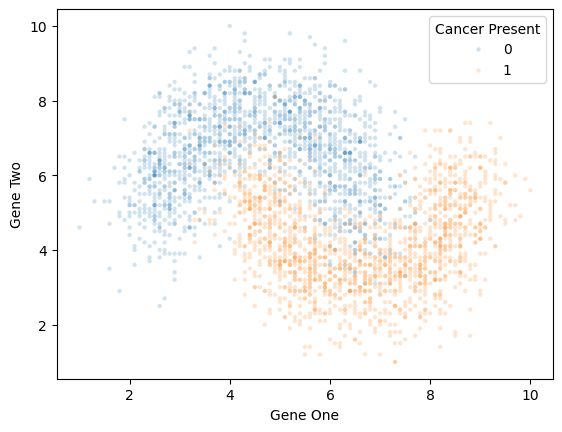

In [7]:
sns.scatterplot(data=df,x='Gene One',y='Gene Two', hue='Cancer Present',alpha=0.2,s=10)

In order to check the area of influence of a new incomming point, you can focus in by using `xlim` and `ylim`, then distiguish better between clases using `style` in addition to `hue`.

(4.0, 8.0)

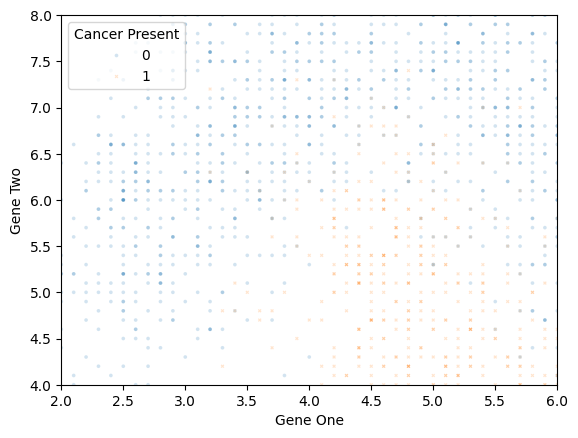

In [8]:
sns.scatterplot(data=df,x='Gene One',y='Gene Two', hue='Cancer Present',alpha=0.2,s=7,style='Cancer Present')
plt.xlim(2,6)
plt.ylim(4,8)

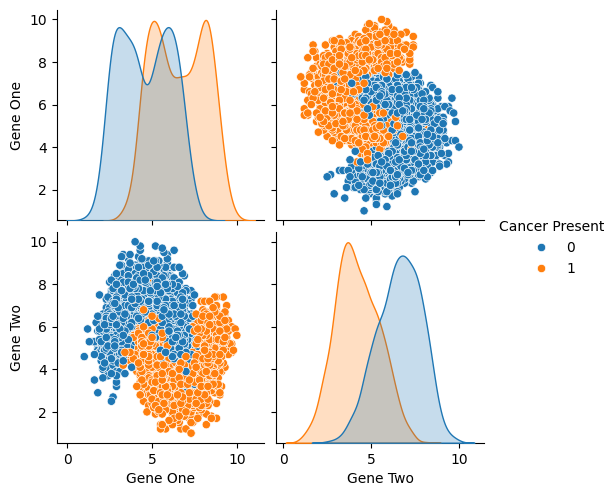

In [9]:
sns.pairplot(data=df,hue='Cancer Present')

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
X = df.drop('Cancer Present',axis=1)
y = df['Cancer Present']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [13]:
scaler = StandardScaler()
scaled_X_train=scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

In [15]:
knn_model=KNeighborsClassifier(n_neighbors=1)
knn_model.fit(scaled_X_train,y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [16]:
y_pred=knn_model.predict(scaled_X_test)

In [17]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report
from sklearn.metrics import precision_score,recall_score,PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay

In [18]:
confusion_matrix(y_test,y_pred)

array([[426,  44],
       [ 45, 385]])

In [19]:
len(y_test)

900

It looks like 89 out of 900 are not classified correctly. Whether that is acceptable or not, deppends on the application.

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       470
           1       0.90      0.90      0.90       430

    accuracy                           0.90       900
   macro avg       0.90      0.90      0.90       900
weighted avg       0.90      0.90      0.90       900



In [22]:
df['Cancer Present'].value_counts()

Cancer Present
1    1500
0    1500
Name: count, dtype: int64

the data set is balanced with respects to the target classes.

### Ideal  number of neighbors
The model is already performing pretty well for just one neighbor. The question is, how good can it get by increasing K.

To investigate that, we can perform the elbow method to see when adding one more neighbor does not pay off the added complexity with enough increase in accuracy.

# Choosing the number of neighbors
We will be using the Pipeline object. In this case we will use to execute insequence the scaler and fit of the model, so it can be reapeated as needed withoug needing separate calls.

In [23]:
from sklearn.metrics import accuracy_score
test_error_rates=[]
for k in range(1,30):
    knn_model=KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train,y_train)
    y_pred_test=knn_model.predict(scaled_X_test)
    test_error=1-accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)

In [24]:
test_error_rates

[0.09888888888888892,
 0.09777777777777774,
 0.07333333333333336,
 0.0755555555555556,
 0.07222222222222219,
 0.06444444444444442,
 0.06444444444444442,
 0.061111111111111116,
 0.05777777777777782,
 0.06222222222222218,
 0.061111111111111116,
 0.06000000000000005,
 0.061111111111111116,
 0.06222222222222218,
 0.05888888888888888,
 0.05777777777777782,
 0.05666666666666664,
 0.05555555555555558,
 0.05222222222222217,
 0.053333333333333344,
 0.054444444444444406,
 0.05111111111111111,
 0.054444444444444406,
 0.054444444444444406,
 0.05666666666666664,
 0.05555555555555558,
 0.05555555555555558,
 0.05777777777777782,
 0.05666666666666664]

Text(0.5, 0, 'K')

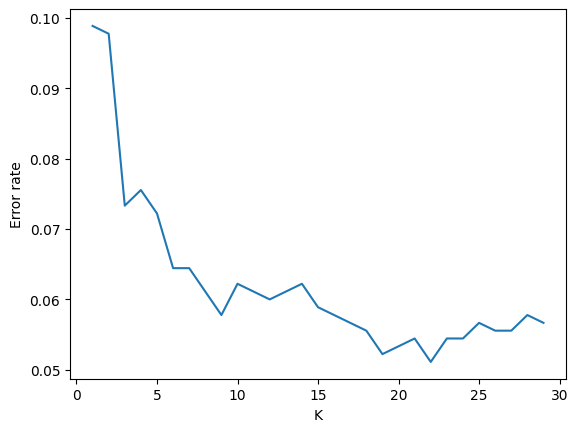

In [25]:
plt.plot(range(1,30),test_error_rates)
plt.ylabel('Error rate')
plt.xlabel('K')

## Using a pipeline
We'll be using a pipeline to use a grid search cross validation

In [27]:
scaler=StandardScaler()
knn=KNeighborsClassifier()

In [28]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

Use the exact same names for the parameters in order for the pipeline to match the elements

In [29]:
operations=[('scaler',scaler),('knn',knn)]

In [30]:
from sklearn.pipeline import Pipeline

In [31]:
pipe = Pipeline(operations)

In [32]:
from sklearn.model_selection import GridSearchCV

In [34]:
k_values = list(range(1,20))
k_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [35]:
param_grid={'knn__n_neighbors':k_values}

In [36]:
full_cv_classifier=GridSearchCV(pipe,param_grid,cv=5,scoring='accuracy')

In [37]:
full_cv_classifier.fit(X_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [39]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=16))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=16),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 16,
 'knn__p': 2,
 'knn__weights': 'uniform'}

We found out that the best K is 16. Now we can run this model to predict new values, or to test its accuracy.

In [41]:
full_predictions=full_cv_classifier.predict(X_test)

In [43]:
print(classification_report(y_test,full_predictions))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       470
           1       0.95      0.93      0.94       430

    accuracy                           0.94       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900



Predict for new set of data

In [44]:
new_patient=[[3.8,6.4]]
full_cv_classifier.predict(new_patient)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [45]:
full_cv_classifier.predict_proba(new_patient)

C:\Users\mvgarcia\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[1., 0.]])

In [ ]:
i.e. No cancer 100% sure.